# Functional Detection

In [26]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import numpy as np
import suite2p
import mbo_utilities as mbo
import lbm_suite2p_python as lsp

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
raw_files = mbo.get_files(r"D:\W2_DATA\wsnyder\2025_03_06\raw\dot_lv6", "tif")

scan = mbo.read_scan(raw_files)

In [18]:
mbo.save_as(scan, "D://demo_functional//assembled", target_chunk_mb=100)

Reading tiff series data...
Reading tiff pages...
Raw tiff fully read.


Saving planes:   0%|          | 0/56 [00:00<?, ?it/s]

Time elapsed: 0 minutes 17 seconds.


In [30]:
assembled_files = mbo.get_files("D://demo_functional//assembled_ws", 'tif')
assembled_files

['D:\\demo_functional\\assembled_ws\\plane_01.tif',
 'D:\\demo_functional\\assembled_ws\\plane_02.tif',
 'D:\\demo_functional\\assembled_ws\\plane_03.tif',
 'D:\\demo_functional\\assembled_ws\\plane_04.tif',
 'D:\\demo_functional\\assembled_ws\\plane_05.tif',
 'D:\\demo_functional\\assembled_ws\\plane_06.tif',
 'D:\\demo_functional\\assembled_ws\\plane_07.tif',
 'D:\\demo_functional\\assembled_ws\\plane_08.tif',
 'D:\\demo_functional\\assembled_ws\\plane_09.tif',
 'D:\\demo_functional\\assembled_ws\\plane_10.tif',
 'D:\\demo_functional\\assembled_ws\\plane_11.tif',
 'D:\\demo_functional\\assembled_ws\\plane_12.tif',
 'D:\\demo_functional\\assembled_ws\\plane_13.tif',
 'D:\\demo_functional\\assembled_ws\\plane_14.tif']

In [ ]:
iw = mbo.run_gui(assembled_files[7])
iw.show()

In [22]:
iw.close()

In [35]:
demo_file = assembled_files[6]

In [ ]:
metadata = mbo.get_metadata(demo_file)
base_ops = mbo.params_from_metadata(metadata, base_ops=suite2p.default_ops())
demo_file,  base_ops["anatomical_only"], base_ops["tau"], base_ops["threshold_scaling"]
base_ops["do_regmetrics"] = True

Setting pipeline to suite2p


## Default parameters except 
- max_overlap = 1.0 to throw out no cells
- tau = 0.3 for GCamP8s

In [15]:
from copy import deepcopy

ops = deepcopy(base_ops)
ops["tau"] = 0.3

In [37]:
output_ops = lsp.run_plane(input_file=demo_file, ops_file=)

Setting pipeline to suite2p
D:\demo_functional\assembled_ws\plane_07.tif already has segmentation results. Skipping execution.
Generating missing plots for plane_07...
Plotting traces...
Plotting noise distribution...
Computing rastermap model...
2025-04-29 10:12:30,973 [INFO] normalizing data across axis=1
2025-04-29 10:12:30,973 [INFO] projecting out mean along axis=0
2025-04-29 10:12:30,973 [INFO] data normalized, 0.00sec
2025-04-29 10:12:30,980 [INFO] sorting activity: 211 valid samples by 903 timepoints
2025-04-29 10:12:31,041 [INFO] n_PCs = 128 computed, 0.07sec
2025-04-29 10:12:31,102 [INFO] 100 clusters computed, time 0.13sec
2025-04-29 10:12:41,181 [INFO] clusters sorted, time 10.21sec
2025-04-29 10:12:41,324 [INFO] clusters upsampled, time 10.35sec
2025-04-29 10:12:41,324 [INFO] rastermap complete, time 10.35sec
Neuron binning factor (default): 5
Plots generated successfully.


In [38]:
res = lsp.load_planar_results(output_ops)
[x for x in res.keys()]

['F', 'Fneu', 'spks', 'stat', 'iscell', 'cellprob', 'z_plane']

In [39]:
iscell = res["iscell"]
sum(iscell), sum(~iscell) # acc, rej

(211, 98)

#### Shot Noise Levels: Compare with [other datasets](https://gcamp6f.com/2021/10/04/large-scale-calcium-imaging-noise-levels/)

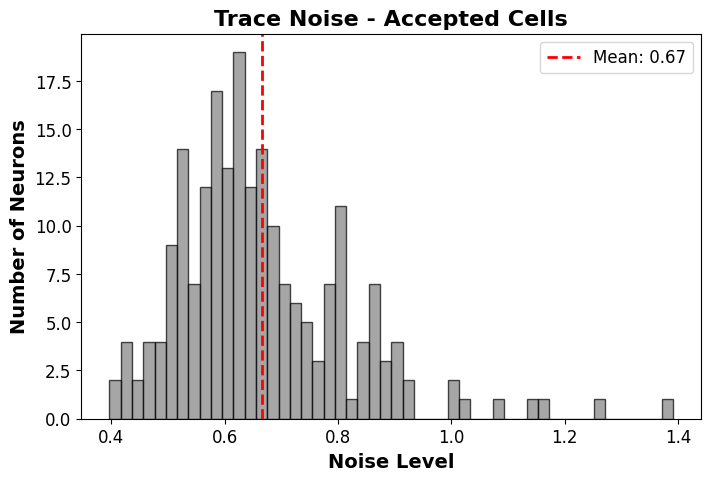

In [45]:
f = res["F"][iscell]           # raw fluo
stat = res["stat"][iscell]     # cell stats (i.e. skewness, measure of activity)
spks = res["spks"][iscell]     # deconvolved spike estimates

dff = lsp.dff_percentile(f, percentile=2) * 100
dff = lsp.uniform_filter1d(dff, size=5, axis=1)
dff_noise = lsp.dff_shot_noise(dff, ops["fs"])
lsp.plot_noise_distribution(dff_noise, title="Trace Noise - Accepted Cells")

Neuron binning factor (default): 1


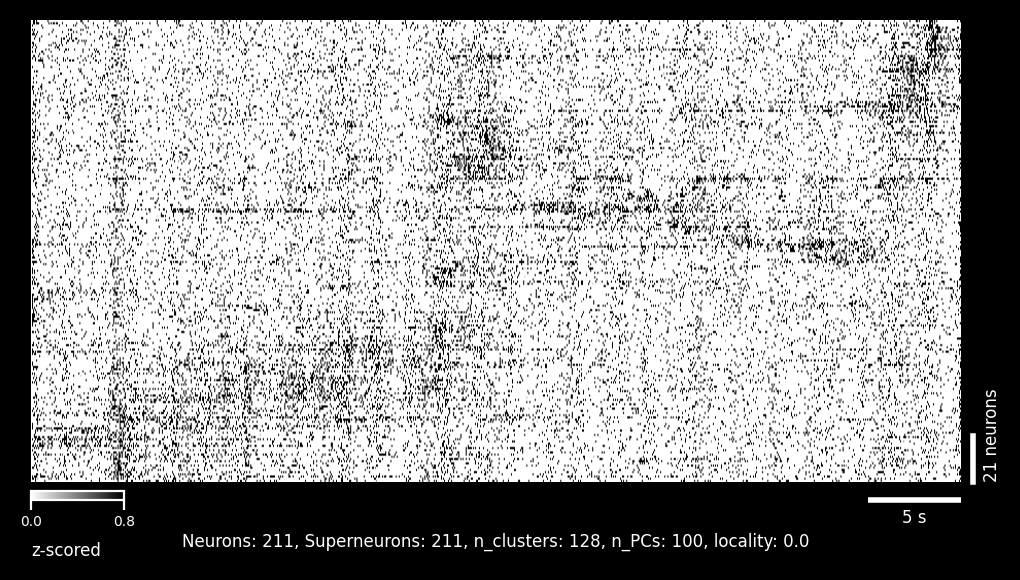

(<Figure size 1200x600 with 2 Axes>, <Axes: >)

In [52]:
model = np.load("D://demo_functional//results//v1//plane0//model.npy", allow_pickle=True).item()
lsp.plot_rastermap( spks=spks, model=model, neuron_bin_size=1)

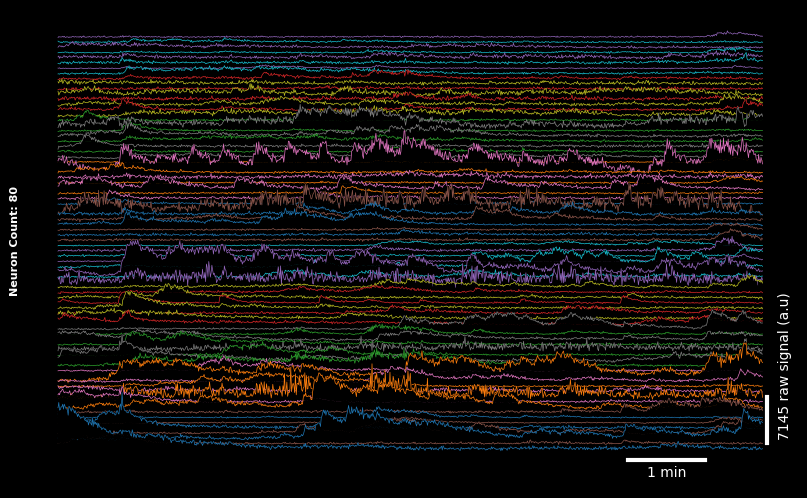

In [78]:
lsp.plot_traces(f, signal_units='raw', num_neurons=80, window=800)

# Sorted by skewness

In [53]:
# stat has statistics for each neuron
stat = res["stat"][iscell]
skews = np.array([x["skew"] for x in stat])
order = np.argsort(-skews)
f_skew_sort = f[order]

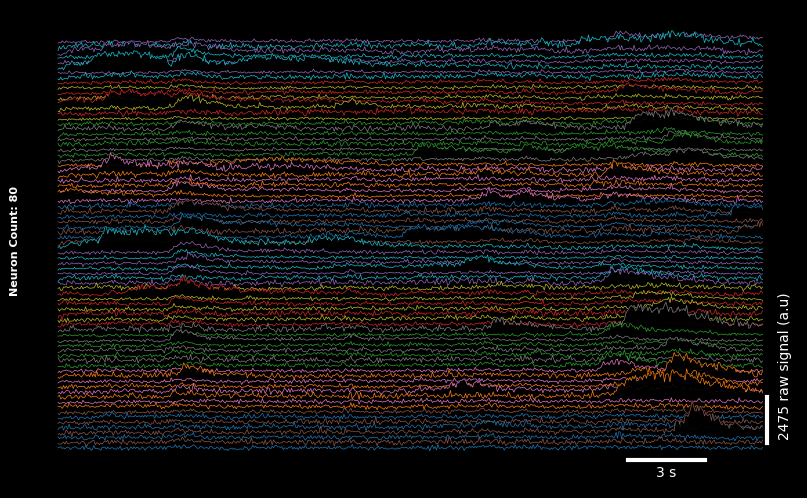

In [54]:
lsp.plot_traces(f_skew_sort, signal_units='raw', num_neurons=80, window=30)

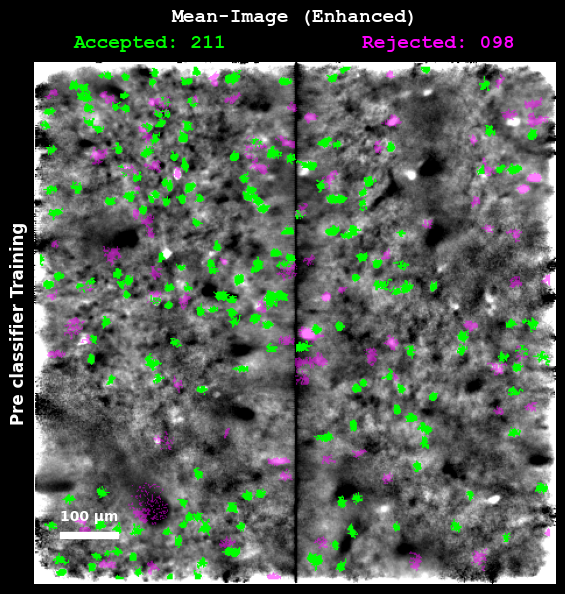

In [55]:
lsp.plot_projection(
    output_ops,
    fig_label="Pre-classifier Training",
    display_masks=True,
    add_scalebar=True,
    proj="meanImgE",
)

In [57]:
ops["classifier_path"] = r"D://mbo_v1.npy"

In [76]:
output_ops = lsp.run_plane(ops, demo_file, "D://demo_functional//results_clv1", save_folder=None, overwrite=False)

D:\demo_functional\assembled_ws\plane_07.tif already has segmentation results. Skipping execution.
Generating missing plots for plane_07...
Plotting traces...
Plotting noise distribution...
Computing rastermap model...
2025-04-29 11:51:49,474 [INFO] normalizing data across axis=1
2025-04-29 11:51:49,484 [INFO] projecting out mean along axis=0
2025-04-29 11:51:49,484 [INFO] data normalized, 0.01sec
2025-04-29 11:51:49,484 [INFO] sorting activity: 330 valid samples by 903 timepoints
2025-04-29 11:51:49,567 [INFO] n_PCs = 128 computed, 0.09sec
2025-04-29 11:51:49,630 [INFO] 100 clusters computed, time 0.16sec
2025-04-29 11:52:07,120 [INFO] clusters sorted, time 17.65sec
2025-04-29 11:52:07,263 [INFO] clusters upsampled, time 17.79sec
2025-04-29 11:52:07,273 [INFO] rastermap complete, time 17.80sec
Neuron binning factor (default): 5
Plots generated successfully.


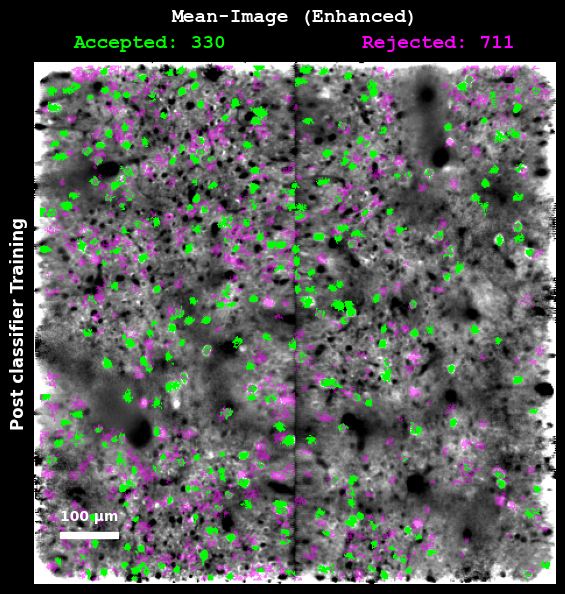

In [77]:
lsp.plot_projection(
    output_ops,
    fig_label="Post-classifier Training",
    display_masks=True,
    add_scalebar=True,
    proj="meanImgE",
)

In [91]:
res = lsp.load_planar_results(output_ops)
iscell = res["iscell"]
f = res["F"][iscell]
iscell.sum()

330

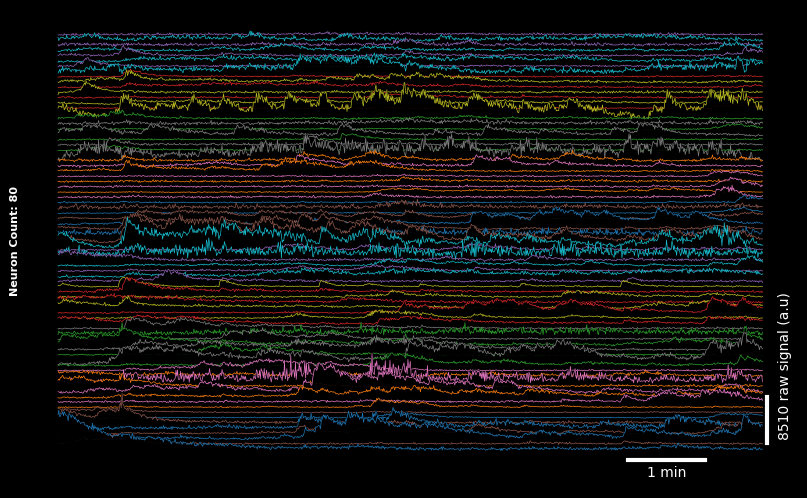

In [92]:
lsp.plot_traces(f, signal_units='raw', num_neurons=80, window=800)

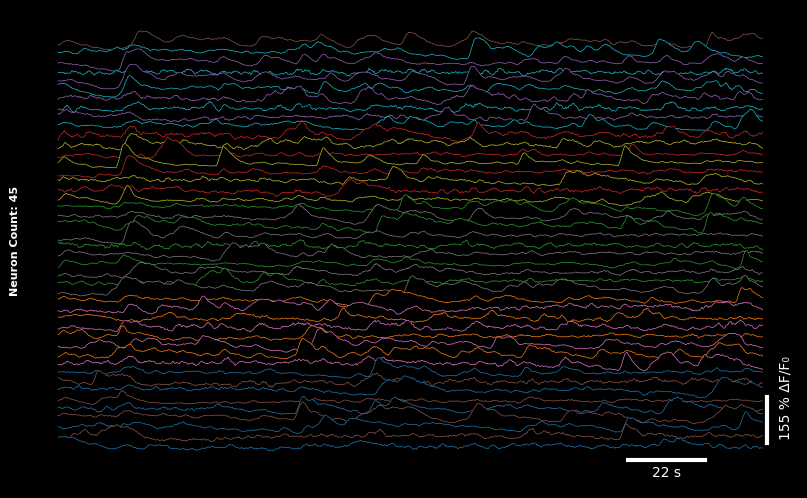

In [121]:
dff = lsp.dff_maxmin(f, ops["fs"], smooth_window=8) * 100
lsp.plot_traces(dff, window=220, num_neurons=45, signal_units="dff")

In [125]:
ops_class = deepcopy(base_ops)
ops_class["tau"] = 0.3
ops_class["classifier_path"] = r"D://mbo_v2.npy"

In [126]:
output_ops = lsp.run_plane(ops=ops_class, input_tiff=demo_file, save_path="D://demo_functional//results", save_folder="v2_classifier", overwrite=False, replot=False)

{'data_path': ['D:\\demo_functional\\assembled_ws'], 'save_folder': 'v2_classifier', 'save_path0': 'D:\\demo_functional\\results', 'tiff_list': ['plane_07.tif']}
tif
** Found 1 tifs - converting to binary **
time 0.87 sec. Wrote 903 frames per binary for 1 planes
>>>>>>>>>>>>>>>>>>>>> PLANE 0 <<<<<<<<<<<<<<<<<<<<<<
NOTE: not registered / registration forced with ops['do_registration']>1
      (no previous offsets to delete)
NOTE: applying classifier D://mbo_v2.npy
----------- REGISTRATION
Reference frame, 7.05 sec.
Registered 500/903 in 7.52s
Registered 903/903 in 13.55s
----------- Total 24.36 sec
----------- ROI DETECTION
Binning movie in chunks of length 05
Binned movie of size [180,442,438] created in 0.32 sec.
NOTE: estimated spatial scale ~6 pixels, time epochs 1.00, threshold 5.00 
0 ROIs, score=163.03
1000 ROIs, score=5.18
Detected 1191 ROIs, 3.51 sec
After removing overlaps, 1041 ROIs remain
----------- Total 4.92 sec.
----------- EXTRACTION
Masks created, 0.55 sec.
Extracted 

## Test classifier v2 on full volume

In [130]:
assembled_files = mbo.get_files("D://demo_classifier", 'tif', 2)
len(assembled_files)  # num z

14

In [ ]:
ops_class2 = deepcopy(base_ops)
ops_class["tau"] = 0.3
ops_class["classifier_path"] = r"D://mbo_v2.npy"
lsp.run_volume(ops_class2, assembled_files, r"D://demo_classifier//results", "v2")

Processing Planes:   0%|          | 0/14 [00:00<?, ?it/s]

Processing D:\demo_classifier\assembled_ws\plane_01.tif ---------------
{'data_path': ['D:\\demo_classifier\\assembled_ws'], 'save_folder': 'v2', 'save_path0': 'D:\\demo_classifier\\results', 'tiff_list': ['plane_01.tif']}
tif
** Found 1 tifs - converting to binary **
time 0.86 sec. Wrote 903 frames per binary for 1 planes
>>>>>>>>>>>>>>>>>>>>> PLANE 0 <<<<<<<<<<<<<<<<<<<<<<
NOTE: not registered / registration forced with ops['do_registration']>1
      (no previous offsets to delete)
NOTE: applying default C:\Users\RBO\.suite2p\classifiers\classifier_user.npy
----------- REGISTRATION
Reference frame, 7.39 sec.
Registered 500/903 in 7.68s
Registered 903/903 in 13.77s
----------- Total 25.07 sec
----------- ROI DETECTION
Binning movie in chunks of length 17
Binned movie of size [53,440,438] created in 0.28 sec.
NOTE: estimated spatial scale ~6 pixels, time epochs 1.00, threshold 5.00 
0 ROIs, score=40.11
Detected 311 ROIs, 1.01 sec
After removing overlaps, 309 ROIs remain
----------- Tot